In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as functional
import torch.optim as optim
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import make_grid
from torch.autograd import Variable
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [8]:

# dados de treinno
train_dataset = MNIST('data/', transform=transforms.ToTensor(), train=True, download=False)
# dados de teste
test_dataset = MNIST('data/', transform=transforms.ToTensor(), train=False, download=False)

# carregando com o data loader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
# classe do autoencoder
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # rede neural do encoder
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc21 = nn.Linear(256, 20)
        self.fc22 = nn.Linear(256, 20)

        # rede neural do decoder
        self.fc3 = nn.Linear(20, 256)
        self.fc4 = nn.Linear(256, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    # função que aplica o encoder
    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        mu = self.fc21(x)
        logvar = self.fc22(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = Variable(torch.randn(std.size()).to(device))
            return eps.mul(std).add_(mu)
        else:
            return mu

    # função que aplica o decoder
    def decode(self, z):
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7)
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z = self.decode(z)
        return z, mu, logvar

In [10]:
# função para treinar o modelo
def train_batch(data,model,optimizer,loss_function):
    model.train()
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch, mean, log_var = model(data)
    loss,mse,kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step()
    return loss, mse, kld, log_var.mean(), mean.mean()

@torch.no_grad()
# função que testa o modelo
def validate_batch(data,model,loss_function):
    model.eval()
    data = data.to(device)
    recon,mean,log_var = model(data)
    loss, mse, kld = loss_function(recon,data,mean,log_var)
    return loss, mse, kld, log_var.mean(), mean.mean()

In [11]:
# função que calcula o valor da perda
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1+log_var-mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD

EPOCH: 1.000  train_mean: 0.001  val_log_var: -0.871  val_mean: -0.006  train_recon: 2401.654  train_log_var: -0.542  val_loss: 1863.358  train_loss: 2774.079  val_recon: 1300.450  val_kld: 562.908  train_kld: 372.425  (26.61s - 239.53s remaining)


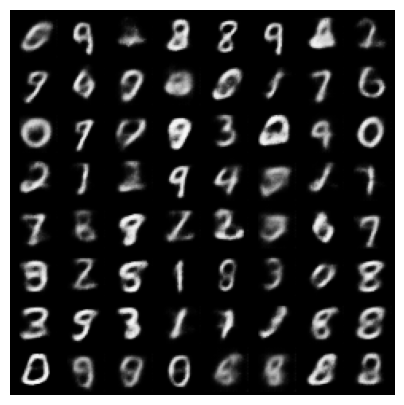

EPOCH: 2.000  train_mean: 0.000  val_log_var: -0.990  val_mean: 0.009  train_recon: 1417.241  train_log_var: -0.967  val_loss: 1667.856  train_loss: 2040.699  val_recon: 1028.094  val_kld: 639.762  train_kld: 623.459  (59.10s - 236.42s remaining)


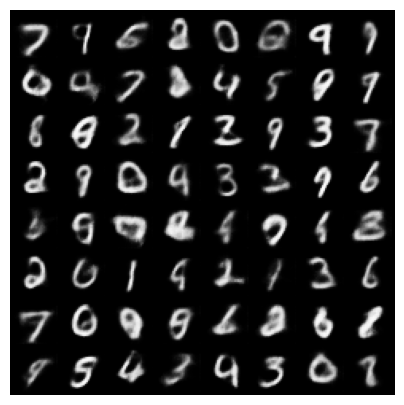

EPOCH: 3.000  train_mean: 0.000  val_log_var: -1.033  val_mean: 0.012  train_recon: 1276.835  train_log_var: -1.040  val_loss: 1612.429  train_loss: 1944.287  val_recon: 944.423  val_kld: 668.005  train_kld: 667.451  (91.94s - 214.52s remaining)


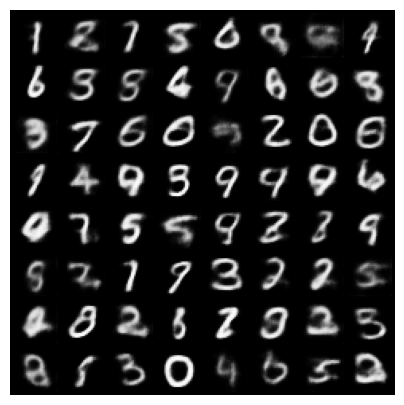

EPOCH: 4.000  train_mean: 0.000  val_log_var: -1.075  val_mean: 0.016  train_recon: 1202.848  train_log_var: -1.074  val_loss: 1565.406  train_loss: 1891.150  val_recon: 892.235  val_kld: 673.171  train_kld: 688.302  (124.61s - 186.92s remaining)


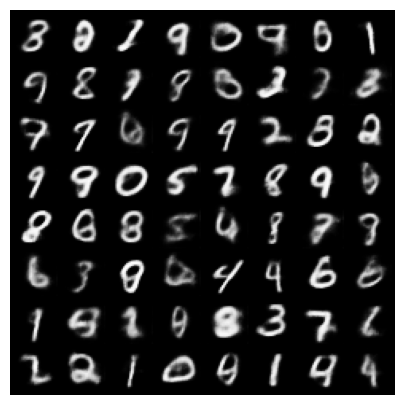

EPOCH: 5.000  train_mean: 0.000  val_log_var: -1.109  val_mean: 0.005  train_recon: 1155.024  train_log_var: -1.100  val_loss: 1545.546  train_loss: 1859.498  val_recon: 840.062  val_kld: 705.484  train_kld: 704.473  (156.27s - 156.27s remaining)


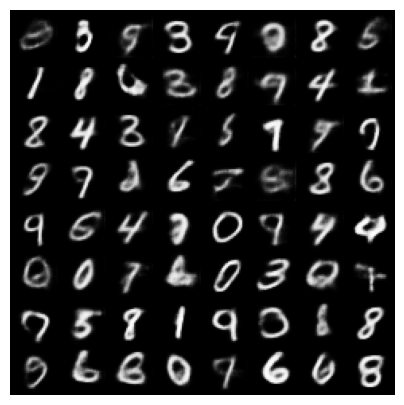

EPOCH: 6.000  train_mean: -0.000  val_log_var: -1.141  val_mean: 0.003  train_recon: 1122.407  train_log_var: -1.115  val_loss: 1542.443  train_loss: 1836.257  val_recon: 815.844  val_kld: 726.599  train_kld: 713.850  (188.63s - 125.75s remaining)


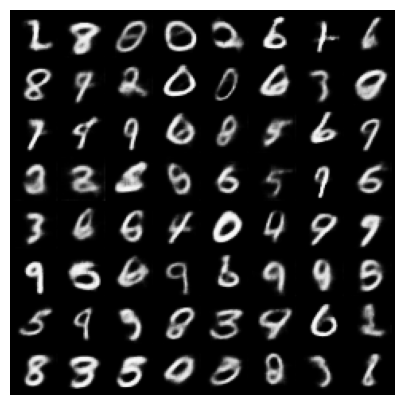

EPOCH: 7.000  train_mean: -0.000  val_log_var: -1.170  val_mean: 0.020  train_recon: 1099.553  train_log_var: -1.126  val_loss: 1570.389  train_loss: 1819.542  val_recon: 803.893  val_kld: 766.496  train_kld: 719.989  (232.66s - 99.71s remaining)


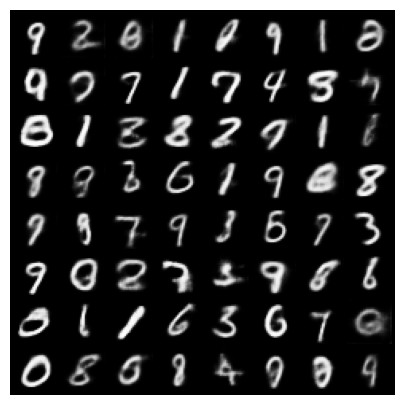

EPOCH: 8.000  train_mean: -0.000  val_log_var: -1.117  val_mean: 0.022  train_recon: 1080.933  train_log_var: -1.135  val_loss: 1503.784  train_loss: 1807.004  val_recon: 801.367  val_kld: 702.417  train_kld: 726.071  (265.38s - 66.34s remaining)


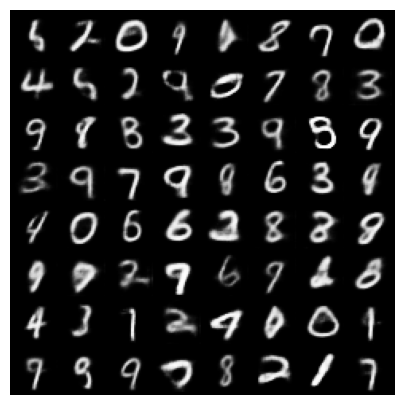

EPOCH: 9.000  train_mean: 0.001  val_log_var: -1.149  val_mean: 0.006  train_recon: 1063.948  train_log_var: -1.143  val_loss: 1508.773  train_loss: 1795.486  val_recon: 783.534  val_kld: 725.239  train_kld: 731.538  (296.87s - 32.99s remaining)


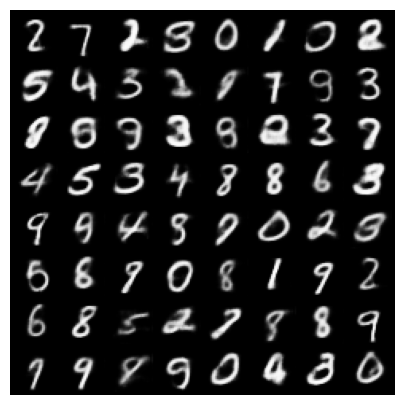

EPOCH: 10.000  train_mean: -0.000  val_log_var: -1.155  val_mean: -0.023  train_recon: 1050.158  train_log_var: -1.150  val_loss: 1506.444  train_loss: 1785.566  val_recon: 776.307  val_kld: 730.137  train_kld: 735.408  (328.80s - 0.00s remaining)


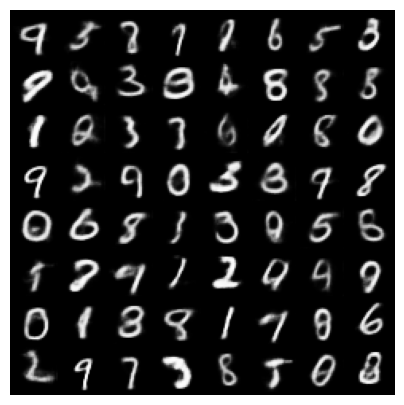

In [12]:
# definindo variáveis importantes
n_epochs = 10
log = Report(n_epochs)
vae = VAE().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

# épocas de treinamento
for epoch in range(n_epochs):
    N = len(train_loader)

    # trainemtno do encoder
    for batch_idx, (data, _) in enumerate(train_loader):
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')

    N = len(test_loader)

    # teste do encoder
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')

    # recriação de imagens com o encoder
    log.report_avgs(epoch+1)
    with torch.no_grad():
        z = torch.randn(64, 20).to(device)
        sample = vae.decode(z).to(device)
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
        show(images)